
 Binary Encoding for Crops:
--------------------------------
Crop Name      →  Code
Groundnut       →  0
Ragi            →  1
Red Gram        →  2
--------------------------------
 Initial Model Validation Accuracy: 94.54%
 Initial Model Test Accuracy: 92.69%
Fitting 5 folds for each of 24 candidates, totalling 120 fits
 Best Hyperparameters (from GridSearchCV): {'criterion': 'gini', 'max_depth': 6, 'min_samples_split': 10}
 Validation Accuracy (GridSearch): 87.75%
 Test Accuracy (GridSearch): 87.90%

 Manual K-Fold search for best model based on accuracy...

Params: depth=3, split=2, criterion=gini => Avg Accuracy = 79.32%
Params: depth=3, split=2, criterion=entropy => Avg Accuracy = 78.81%
Params: depth=3, split=5, criterion=gini => Avg Accuracy = 79.32%
Params: depth=3, split=5, criterion=entropy => Avg Accuracy = 78.81%
Params: depth=3, split=10, criterion=gini => Avg Accuracy = 79.32%
Params: depth=3, split=10, criterion=entropy => Avg Accuracy = 78.81%
Params: depth=4, split=2, 

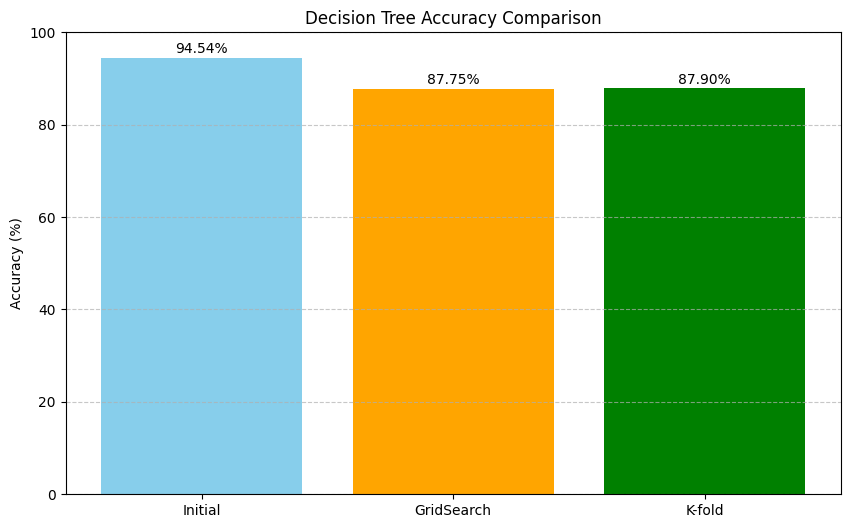

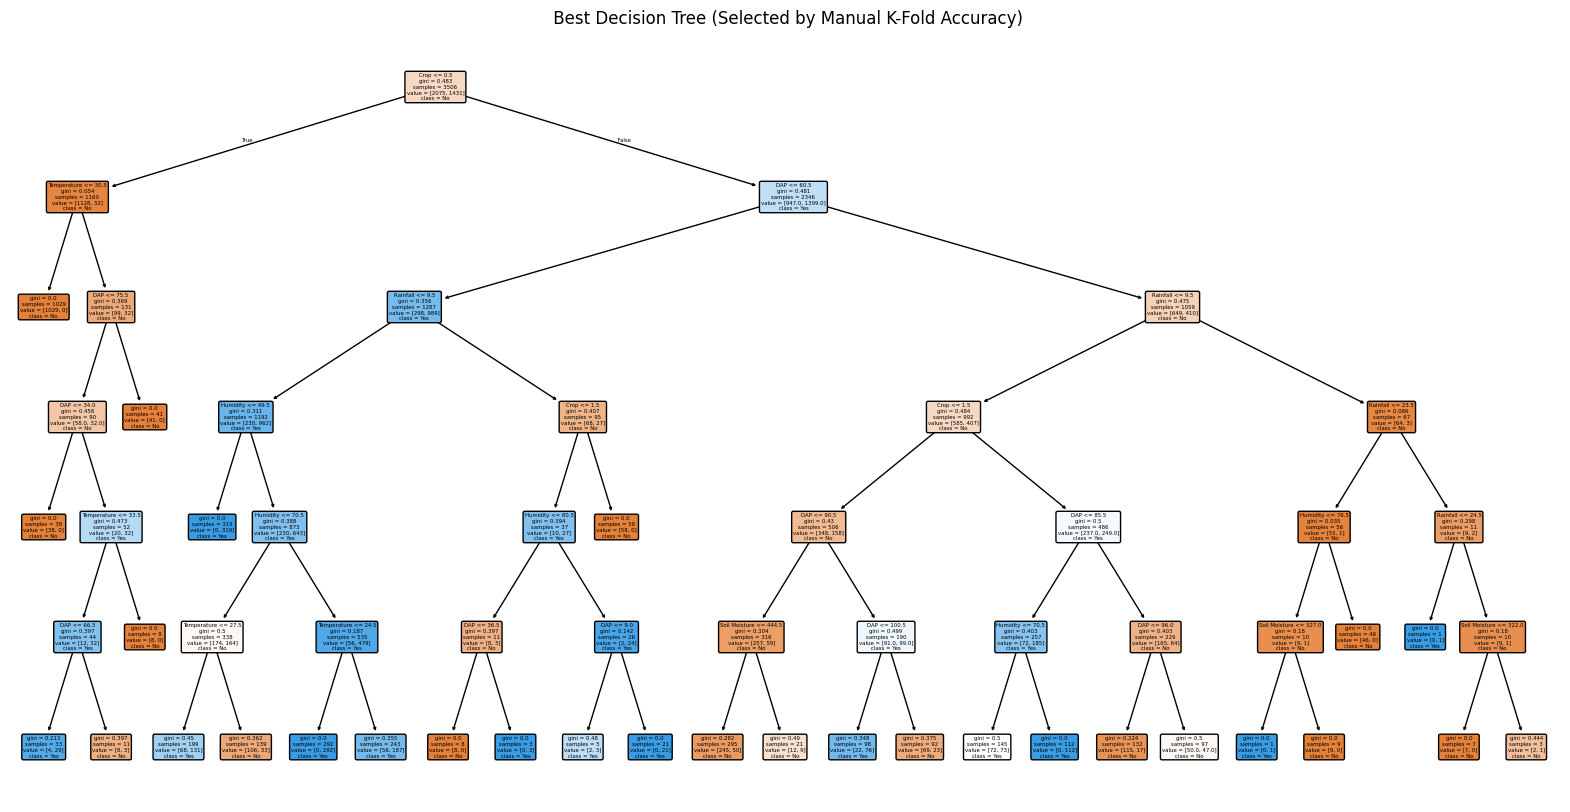


void predict_irrigation(...) {
if (Crop <= 0.5000) {
  if (Temperature <= 30.5000) {
    return "No";
  } else {
    if (DAP <= 75.5000) {
      if (DAP <= 34.0000) {
        return "No";
      } else {
        if (Temperature <= 33.5000) {
          if (DAP <= 66.5000) {
            return "Yes";
          } else {
            return "No";
          }
        } else {
          return "No";
        }
      }
    } else {
      return "No";
    }
  }
} else {
  if (DAP <= 60.5000) {
    if (Rainfall <= 9.5000) {
      if (Humidity <= 49.5000) {
        return "Yes";
      } else {
        if (Humidity <= 70.5000) {
          if (Temperature <= 27.5000) {
            return "Yes";
          } else {
            return "No";
          }
        } else {
          if (Temperature <= 24.5000) {
            return "Yes";
          } else {
            return "Yes";
          }
        }
      }
    } else {
      if (Crop <= 1.5000) {
        if (Humidity <= 80.5000) {
          if (DAP <=

In [13]:
# Step 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, log_loss

# Step 2: Load Data
df = pd.read_csv('datasetfinal.csv')

# Step 3: Encode Categorical Columns
le_crop = LabelEncoder()
le_irrigation = LabelEncoder()

df['Crop'] = le_crop.fit_transform(df['Crop'])
df['irrigation needed'] = le_irrigation.fit_transform(df['irrigation needed'])

# Print Binary Mapping
crop_mapping = dict(zip(le_crop.classes_, le_crop.transform(le_crop.classes_)))
print("\n Binary Encoding for Crops:")
print("--------------------------------")
print("Crop Name      →  Code")
for crop, code in crop_mapping.items():
    print(f"{crop:<15} →  {code}")
print("--------------------------------")

# Step 4: Split Data
X = df.drop('irrigation needed', axis=1)
y = df['irrigation needed']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# ---------- INITIAL MODEL ----------
initial_model = DecisionTreeClassifier(random_state=42)
initial_model.fit(X_train, y_train)

acc_val_initial = accuracy_score(y_val, initial_model.predict(X_val))
acc_test_initial = accuracy_score(y_test, initial_model.predict(X_test))
print(f" Initial Model Validation Accuracy: {acc_val_initial * 100:.2f}%")
print(f" Initial Model Test Accuracy: {acc_test_initial * 100:.2f}%")

# ---------- GRID SEARCH ----------
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)
print(" Best Hyperparameters (from GridSearchCV):", grid_search.best_params_)

gs_best_model = grid_search.best_estimator_
val_acc_gs = accuracy_score(y_val, gs_best_model.predict(X_val))
test_acc_gs = accuracy_score(y_test, gs_best_model.predict(X_test))
print(f" Validation Accuracy (GridSearch): {val_acc_gs * 100:.2f}%")
print(f" Test Accuracy (GridSearch): {test_acc_gs * 100:.2f}%")

# ---------- MANUAL K-FOLD SELECTION ----------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_model = None
best_params = None
best_avg_kfold_acc = 0

print("\n Manual K-Fold search for best model based on accuracy...\n")

for depth in param_grid['max_depth']:
    for split in param_grid['min_samples_split']:
        for crit in param_grid['criterion']:
            kfold_accuracies = []

            for train_index, val_index in kf.split(X_train, y_train):
                X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
                y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

                model = DecisionTreeClassifier(max_depth=depth, min_samples_split=split,
                                               criterion=crit, random_state=42)
                model.fit(X_train_fold, y_train_fold)
                kfold_accuracies.append(accuracy_score(y_val_fold, model.predict(X_val_fold)))

            avg_acc = sum(kfold_accuracies) / len(kfold_accuracies)
            print(f"Params: depth={depth}, split={split}, criterion={crit} => Avg Accuracy = {avg_acc * 100:.2f}%")

            if avg_acc > best_avg_kfold_acc:
                best_avg_kfold_acc = avg_acc
                best_params = (depth, split, crit)
                best_model = DecisionTreeClassifier(max_depth=depth, min_samples_split=split,
                                                    criterion=crit, random_state=42)
                best_model.fit(X_train, y_train)

print("\n Best Hyperparameters (Manual K-Fold):", best_params)
print(f" Best Average K-Fold Accuracy: {best_avg_kfold_acc * 100:.2f}%")

val_acc_kfold = accuracy_score(y_val, best_model.predict(X_val))
test_acc_kfold = accuracy_score(y_test, best_model.predict(X_test))
print(f"Final Model Validation Accuracy: {val_acc_kfold * 100:.2f}%")
print(f"Final Model Test Accuracy: {test_acc_kfold * 100:.2f}%")

# ---------- ACCURACY COMPARISON GRAPH ----------
labels = ['Initial', 'GridSearch', 'K-fold']
accuracies = [acc_val_initial, val_acc_gs, test_acc_kfold]

plt.figure(figsize=(10, 6))
plt.bar(labels, [acc * 100 for acc in accuracies], color=['skyblue', 'orange', 'green'])
plt.ylabel('Accuracy (%)')
plt.title('Decision Tree Accuracy Comparison')
plt.ylim(0, 100)
for i, acc in enumerate(accuracies):
    plt.text(i, acc * 100 + 1, f'{acc * 100:.2f}%', ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# ---------- FINAL MODEL VISUALIZATION ----------
plt.figure(figsize=(20, 10))
plot_tree(best_model, feature_names=X.columns, class_names=le_irrigation.classes_,
          filled=True, rounded=True, impurity=True)
plt.title(" Best Decision Tree (Selected by Manual K-Fold Accuracy)")
plt.show()

# ---------- EXTRACT RULES TO C-LIKE CODE ----------
def extract_rules_from_tree(tree, feature_names, class_names, node=0, depth=0):
    indent = "  " * depth
    if tree.feature[node] != -2:
        name = feature_names[tree.feature[node]]
        threshold = tree.threshold[node]
        left_rule = extract_rules_from_tree(tree, feature_names, class_names, tree.children_left[node], depth + 1)
        right_rule = extract_rules_from_tree(tree, feature_names, class_names, tree.children_right[node], depth + 1)
        return (f"{indent}if ({name} <= {threshold:.4f}) {{\n"
                f"{left_rule}"
                f"{indent}}} else {{\n"
                f"{right_rule}"
                f"{indent}}}\n")
    else:
        value = tree.value[node][0]
        predicted_class = class_names[value.argmax()]
        return f"{indent}return \"{predicted_class}\";\n"

tree = best_model.tree_
feature_names = list(X.columns)
class_names = le_irrigation.classes_

rules = extract_rules_from_tree(tree, feature_names, class_names)
print("\nvoid predict_irrigation(...) {\n" + rules + "}")
